In [1]:
import os
MAIN_DIR='/home/jovyan/code4'
os.chdir(MAIN_DIR)
print(os.getcwd())

/home/jovyan/code4


In [2]:
import json
import numpy as np
import scipy.sparse.linalg as sprse
import pickle
import random
import os
from pathlib import Path as Data_Path
from basic_types import JSONFile
from tqdm import tqdm
import networkx as nx
from networkx.algorithms import bipartite
from graph_building_routines import graph_attribute_builder

import matplotlib.pyplot as plt
import matplotlib
plt.rcParams.update({ "text.usetex": True, "font.family": "serif" })
font = {'size': 16}
matplotlib.rc('font', **font)
fmt = 'pdf'
%matplotlib inline

In [13]:
def playlist_track_JSON_loader(JSONs):
  playlist_data = {}
  playlists = []
  tracks = []
  artists = []
  playlist_track_edges = []
  track_artist_edges = []
  # build list of all unique playlists, tracks, and artists 
  for json_file in tqdm(JSONs):
    playlists += [p.name for p in json_file.playlists.values()]
    tracks += [track.uri for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
    artists += [track.artist_uri for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
    
    playlist_track_edges += [(playlist.name, track.uri) for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]
    track_artist_edges += [(track.uri, track.artist_uri) for playlist in json_file.playlists.values() for track in list(playlist.tracks.values())]

    playlist_data = playlist_data | json_file.playlists
  return playlists, tracks, artists, playlist_track_edges, track_artist_edges, playlist_data


In [ ]:
DATA_PATH = Data_Path('data')
file_names_to_use = sorted([f for f in os.listdir(DATA_PATH) 
                            if os.path.isfile(os.path.join(DATA_PATH, f)) and f.endswith('.json')])


# set the seed for reproducibility
seed = 224
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


n_playlists = 0

# load each json file, and store it in a list of files
JSONs = []
for file_name in tqdm(file_names_to_use, desc='Files processed: ', unit='files', total=len(file_names_to_use)):
  json_file = JSONFile(DATA_PATH, file_name, n_playlists)
  json_file.process_file()
  n_playlists += len(json_file.playlists)
  JSONs.append(json_file)

playlists, tracks, artists, playlist_track, track_artist, playlist_data = playlist_track_JSON_loader(JSONs)

N_FILES_TO_USE=30

In [3]:
Gred = pickle.load(open(f"{30}core_first_{30}.pkl", "rb"))

#kcore_selected_artist = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="artist"]
kcore_selected_playlists = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="playlist"]
kcore_selected_tracks = [x for x,y in Gred.nodes(data=True) if y["node_type"]=="track"]
num_playlists = len(kcore_selected_playlists)
num_tracks = len(kcore_selected_tracks)
#num_artist = len(kcore_selected_artist)
print(f"Number of kcore selected playlists: {num_playlists}")
print(f"Number of kcore selected tracks: {num_tracks}")
#print(f"NUmber of kcore slected artists: {num_artist}")

Number of kcore selected playlists: 12322
Number of kcore selected tracks: 7669


In [4]:
def subgraph_count(bmat, degrees):

    # A = (0 bmat \\ bmat.T 0)
    # A2 = (bmat@bmat.T 0 \\ 0 bmat.T@bmat)
    # we leverage the block structure in order to speed up computation.  

    fvec = np.zeros(5)
    nplylsts, ntrcks = bmat.shape
    nds = nplylsts + ntrcks

    dgs = np.zeros((nds, 1), dtype=int)
    ovec = np.ones((nds, 1), dtype=int)
    dfvec = np.zeros((nds, 1), dtype=int)
    dftvec = np.zeros((nds, 1), dtype=int)
    dgs[:, 0] = degrees.astype(int)
    dfvec[:, 0] = dgs[:, 0] - ovec[:, 0]
    dftvec[:, 0] = dgs[:, 0] - 2 * ovec[:, 0]

    dfvecu = dfvec[:nplylsts,:]
    dfvecl = dfvec[nplylsts:,:]

    A2u = bmat @ bmat.T
    A2l = bmat.T @ bmat

    P1 = np.sum(dgs)/2    
    P2 = np.sum(dgs*dfvec) / 2.
    A2m1u = A2u.todense()-np.ones(A2u.shape)
    A2m1l = A2l.todense()-np.ones(A2l.shape)
    a2chsu = .5*A2u.todense()*A2m1u
    a2chsl = .5*A2l.todense()*A2m1l

    np.fill_diagonal(a2chsu, 0.)
    np.fill_diagonal(a2chsl, 0.)
    
    a2chsvecu = np.sum(a2chsu, 1)
    a2chsvecl = np.sum(a2chsl, 1)
    a2chsvec = np.concatenate((a2chsvecu, a2chsvecl))

    fvec[0] = P1 # num edges
    fvec[1] = P2 # n_G(H_2)
    fvec[2] = .5*( np.sum( np.sum( bmat*(dfvecu@dfvecl.T) ) ) + np.sum( np.sum( bmat.T*(dfvecl@dfvecu.T) ) ) )# n_G(H_3)
    fvec[3] = np.sum(dgs[:, 0]*dfvec[:, 0]*dftvec[:, 0]) / 6.  # n_G(H_4)    
    fvec[4] = np.dot(dftvec[:,0], a2chsvec) # n_G(H_9)

    return fvec

In [5]:
bmat = bipartite.biadjacency_matrix(Gred, row_order=kcore_selected_playlists, column_order=set(kcore_selected_tracks), dtype=np.float64)
d1 = np.sum(bmat, axis=1)
d2 = np.sum(bmat, axis=0)
degrees = np.concatenate((d1, d2))
print(degrees[:10].astype(int))

[ 32  50  33  58  31 149  68  43  66  44]


In [6]:
fvals = subgraph_count(bmat, degrees)

In [7]:
print(fvals[0])

832153.0


In [7]:
svals = sprse.svds(bmat,k=500,which='LM',return_singular_vectors=False)

153.1224817116101


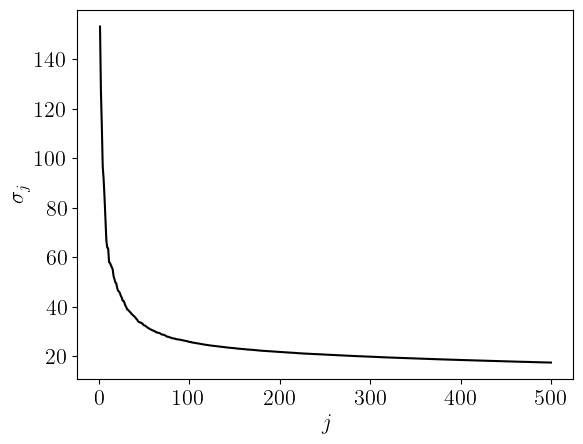

In [ ]:
plt.plot(np.arange(1,len(svals)+1), svals[::-1][:8],color='k')
#plt.xlim([.1, len(svals)])
plt.xlabel(r"$j$")
plt.ylabel(r"$\sigma_j$");
print(svals[-1])
#plt.savefig("singular_values.pdf", dpi=150, bbox_inches='tight')

153.1224817116101


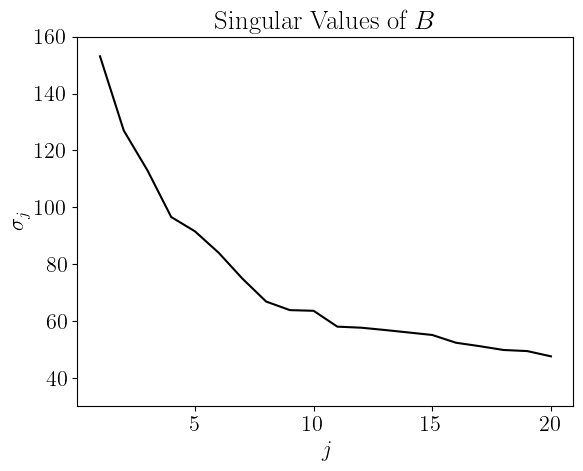

In [35]:
plt.plot(np.arange(1,21), svals[::-1][:20],color='k')
plt.xlabel(r"$j$")
plt.ylabel(r"$\sigma_j$")
plt.ylim(30, 160)
print(svals[-1])
plt.title(r"Singular Values of $B$")
plt.savefig("singular_values.pdf", dpi=150, bbox_inches='tight')


[3.80756873e+08 3.62432332e+12 5.18104491e+16]
127006352.0


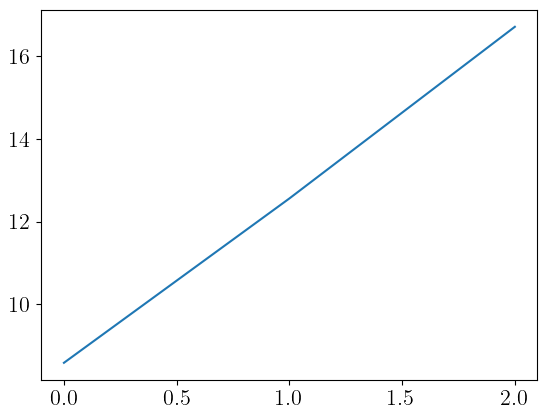

In [8]:
svals2 = svals*svals
svals2k = svals2[:]
kmax = 3
trace_vals = np.zeros(kmax, dtype=np.float64)
for jj in range(kmax):
    svals2k = svals2k*svals2
    kval = jj+2
    #trace_vals[jj] = (np.sum(svals2k) -2*kval*(2**(kval-1)-1)*fvals[1] -2 * fvals[0])/(4.*kval)
    trace_vals[jj] = np.sum(svals2k)/(2.*kval)
print(trace_vals)
print(fvals[1])
plt.plot(np.log10(trace_vals))
#plt.plot((trace_vals))

In [9]:
#C4 formula
C4 = trace_vals[0] - (4*fvals[1]+2*fvals[0])/8
C6 = trace_vals[1] - (24*C4 + 6*fvals[2]+12*fvals[3]+12*fvals[4]+18*fvals[1]+2*fvals[0])/12
print(trace_vals[1])
print(C6)
print(C6/trace_vals[1])

3624323315196.881
3287996407056.944
0.9072028406710545


5


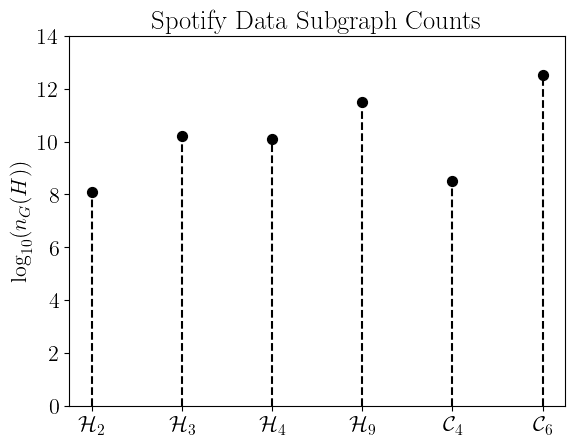

In [10]:
labels=[r'$\mathcal{H}_2$', r'$\mathcal{H}_3$', r'$\mathcal{H}_4$', r'$\mathcal{H}_9$', r'$\mathcal{C}_4$', r'$\mathcal{C}_6$']
print(fvals.size)
plotvals = np.concatenate((fvals[1:],np.array([C4, C6])))
fig, ax = plt.subplots()
ax.set_ylabel(r"$\log_{10}(n_{G}(H))$")
ax.scatter(np.arange(6),np.log10(plotvals),c='k',s=50.)
for jj in range(len(labels)):
    plt.plot([jj, jj], [0, np.log10(plotvals[jj])], c='k', ls='--')
ax.set_ylim([0,14])
ax.set_xticks(np.arange(6))
ax.set_xticklabels(labels);
plt.title("Spotify Data Subgraph Counts")
plt.savefig("s_subgraph_count.pdf", dpi=150, bbox_inches='tight')